# ML Pipeline Frontend

Interactive interface for running ensemble ML experiments on bioinformatics datasets.
Connects to the orchestration service API at http://localhost:8000

In [1]:
import requests
import json
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ORCHESTRATION_URL = "http://localhost:8000"
API_ENDPOINT = f"{ORCHESTRATION_URL}/api/pipeline/run"

print(f"✓ Configured to use: {API_ENDPOINT}")

✓ Configured to use: http://localhost:8000/api/pipeline/run


## Configure and Run Pipeline

In [2]:
# Define pipeline payload directly
payload = {
    #"osd_ids": "47,48,137,168",
    "osd_ids": "137",
    "config": {
        "target_column": "Factor Value[Spaceflight]",
        "task_type": "classification",
        "trans_list": "s,l",  # s=standardize, l=log transform
        #"ensemble_algorithms": ["random_forest", "logistic_regression", "xgboost", "svm", "neural_network"],
        "ensemble_algorithms": ["neural_network"],
        "hyperparameters": {},
        #"metrics": ["accuracy", "precision", "recall", "f1_score"],
        "metrics": ["accuracy"],
        "test_size": 0.2,
        "random_state": 42,
        "min_features": 2000,
        "factor_name": "Factor Value[Spaceflight]",
        "factor_values": ["Ground Control", "Space Flight"],
        #"fi_methods": ["permutation", "recursive"],
        "fi_methods": ["permutation"],
        "convert_ensembl_to_symbol": True,
    }
}

print("Pipeline Configuration:")
print(f"  OSD IDs: {payload['osd_ids']}")
for key, value in payload['config'].items():
    print(f"  {key}: {value}")

Pipeline Configuration:
  OSD IDs: 137
  target_column: Factor Value[Spaceflight]
  task_type: classification
  trans_list: s,l
  ensemble_algorithms: ['neural_network']
  hyperparameters: {}
  metrics: ['accuracy']
  test_size: 0.2
  random_state: 42
  min_features: 2000
  factor_name: Factor Value[Spaceflight]
  factor_values: ['Ground Control', 'Space Flight']
  fi_methods: ['permutation']
  convert_ensembl_to_symbol: True


## Execute Pipeline

In [3]:
def run_pipeline(payload):
    """Run pipeline with ensemble algorithms and handle streaming responses"""
    
    config = payload['config']
    print(f"Sending request to {API_ENDPOINT}")
    print(f"  OSD IDs: {payload['osd_ids']}")
    print(f"  Algorithms: {', '.join(config['ensemble_algorithms'])}")
    print(f"  Min Features: {config['min_features']}")
    print(f"  Transformations: {config['trans_list']}")
    print(f"\\nThis may take several minutes...\\n")
    
    try:
        response = requests.post(
            API_ENDPOINT,
            json=payload,
            stream=True,
            timeout=600
        )
        
        if response.status_code == 200:
            # Process streaming NDJSON responses
            result = None
            for line in response.iter_lines():
                if line:
                    chunk = json.loads(line)
                    progress = chunk.get('progress_percent', 0)
                    status = chunk.get('status', 'running')
                    message = chunk.get('message', '')
                    
                    print(f"[{progress:3d}%] {status}: {message}")
                    result = chunk
            
            print("\\n✓ Pipeline completed!")
            return result
        else:
            print(f"✗ Error: {response.status_code}")
            print(response.text)
            return None
    except Exception as e:
        print(f"✗ Exception: {e}")
        return None

result = run_pipeline(payload)

Sending request to http://localhost:8000/api/pipeline/run
  OSD IDs: 137
  Algorithms: neural_network
  Min Features: 2000
  Transformations: s,l
\nThis may take several minutes...\n
[ 10%] transforming: Applying transformations: s,l...
[ 30%] transforming: Transformations completed
[ 25%] filtering: Filtering features by CV...
[ 30%] filtering: Filtered to 2001 features
[ 32%] converting: Converting feature names...
[ 33%] converting: Converted 1979 Ensembl IDs to gene symbols
[ 65%] training: Training 1 models
[ 85%] deseq2: Running DESeq2 differential expression analysis...
[ 90%] deseq2: DESeq2: 0 significant genes (0 up, 0 down)
[100%] completed: Pipeline completed successfully
\n✓ Pipeline completed!


## Display Results

In [4]:
if result:
    print("\\n" + "="*80)
    print("PIPELINE RESULTS - ENSEMBLE TRAINING")
    print("="*80)
    
    cfg = result.get('config', {})
    print(f"\\nConfiguration:")
    print(f"  Algorithms: {', '.join(cfg.get('algorithms', []))}")
    print(f"  Target: {cfg.get('target_column')}")
    print(f"  OSD IDs: {cfg.get('osd_ids')}")
    print(f"  Test Size: {cfg.get('test_size')}")
    print(f"  Min Features: {cfg.get('min_features')}")
    
    train = result.get('training_results', {})
    test_metrics = train.get('test_metrics', {})
    
    print(f"\\nEnsemble Training Results:")
    print(f"  Total Models: {test_metrics.get('num_models', 0)}")
    print(f"  Mean Accuracy: {test_metrics.get('mean_accuracy', 0):.4f}")
    
    models = test_metrics.get('models', [])
    if models:
        print(f"\\n  Individual Model Performance:")
        for model in models:
            algo = model.get('algorithm', 'unknown')
            acc = model.get('accuracy', 0)
            prec = model.get('precision', 0)
            rec = model.get('recall', 0)
            f1 = model.get('f1_score', 0)
            print(f"    {algo:20s} → Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")
    
    # Feature importance summary
    fi = result.get('feature_importance', {})
    if fi:
        print(f"\\n  Feature Importance:")
        print(f"    Models with importance: {len(fi)}")
        for model_id in list(fi.keys())[:3]:
            methods = fi[model_id]
            print(f"    {model_id}: {len(methods)} methods computed")
else:
    print("Run pipeline first")

\n================================================================================
PIPELINE RESULTS - ENSEMBLE TRAINING
\nConfiguration:
  Algorithms: neural_network
  Target: Factor Value[Spaceflight]
  OSD IDs: 137
  Test Size: 0.2
  Min Features: 2000
\nEnsemble Training Results:
  Total Models: 1
  Mean Accuracy: 0.6667
\n  Individual Model Performance:
    neural_network       → Acc: 0.6667, Prec: 0.4444, Rec: 0.6667, F1: 0.5333
\n  Feature Importance:
    Models with importance: 1
    model_22003b0982d1: 1 methods computed


## Visualize Ensemble Model Performance

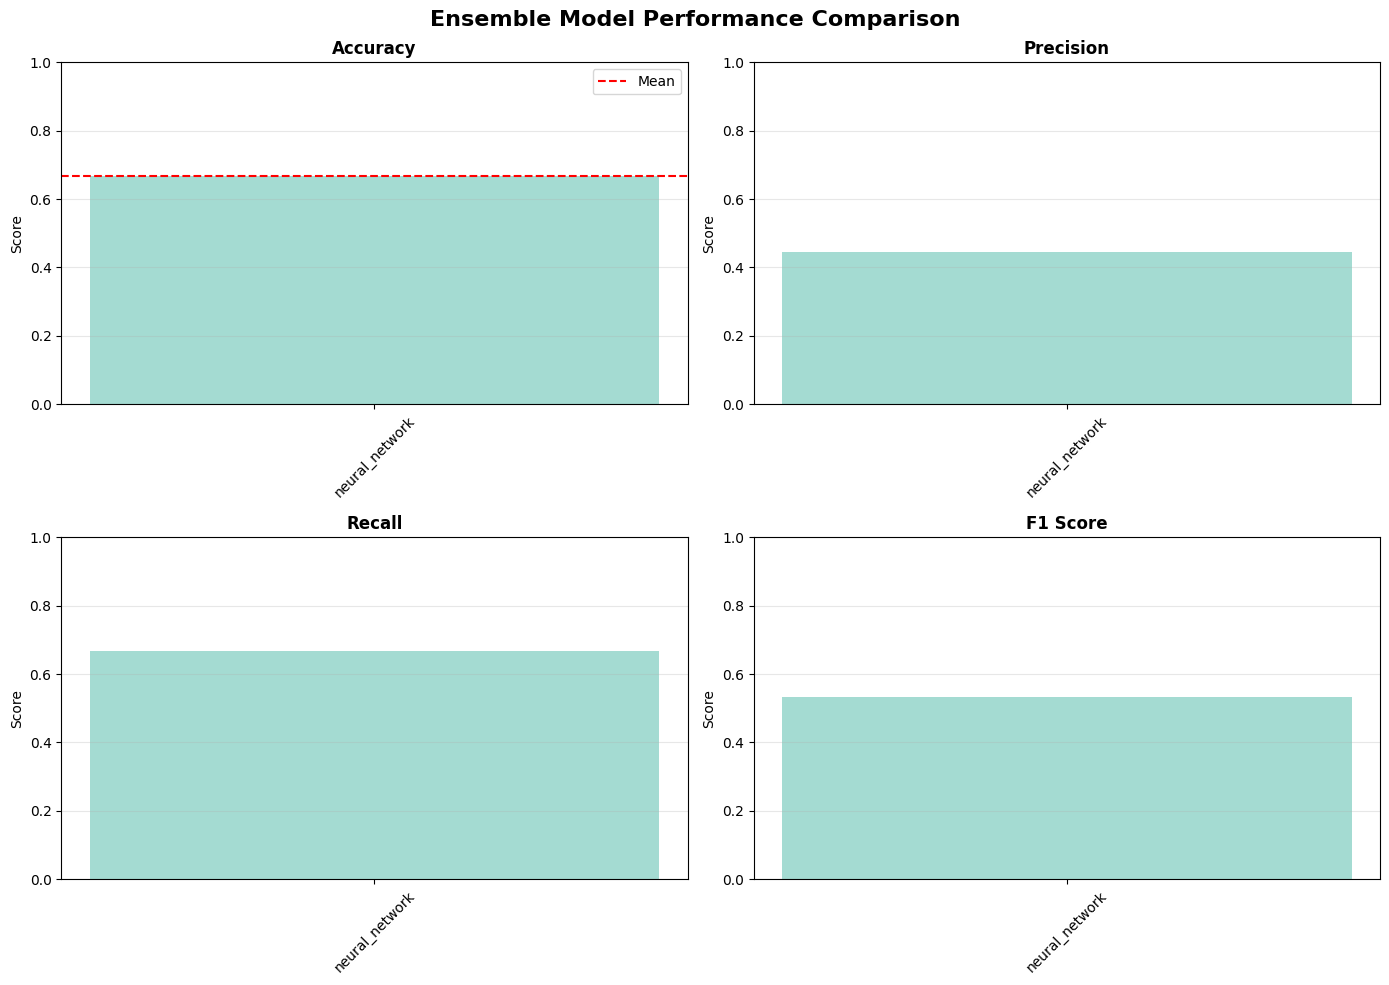

\nModel Ranking (by Accuracy):
           Algorithm  Accuracy  Precision    Recall        F1
Rank                                                         
1     neural_network  0.666667   0.444444  0.666667  0.533333


In [5]:
if result:
    train = result.get('training_results', {})
    test_metrics = train.get('test_metrics', {})
    models = test_metrics.get('models', [])
    
    if models and len(models) > 0:
        # Extract metrics for each model
        model_names = [m.get('algorithm', 'unknown') for m in models]
        accuracies = [m.get('accuracy', 0) for m in models]
        precisions = [m.get('precision', 0) for m in models]
        recalls = [m.get('recall', 0) for m in models]
        f1_scores = [m.get('f1_score', 0) for m in models]
        
        # Create comparison plot
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Ensemble Model Performance Comparison', fontsize=16, fontweight='bold')
        
        # Accuracy
        colors = plt.cm.Set3(np.linspace(0, 1, len(model_names)))
        axes[0, 0].bar(model_names, accuracies, color=colors, alpha=0.8)
        axes[0, 0].set_title('Accuracy', fontsize=12, fontweight='bold')
        axes[0, 0].set_ylabel('Score')
        axes[0, 0].set_ylim([0, 1])
        axes[0, 0].grid(axis='y', alpha=0.3)
        axes[0, 0].axhline(y=test_metrics.get('mean_accuracy', 0.5), color='red', linestyle='--', label='Mean')
        axes[0, 0].legend()
        axes[0, 0].tick_params(axis='x', rotation=45)
        
        # Precision
        axes[0, 1].bar(model_names, precisions, color=colors, alpha=0.8)
        axes[0, 1].set_title('Precision', fontsize=12, fontweight='bold')
        axes[0, 1].set_ylabel('Score')
        axes[0, 1].set_ylim([0, 1])
        axes[0, 1].grid(axis='y', alpha=0.3)
        axes[0, 1].tick_params(axis='x', rotation=45)
        
        # Recall
        axes[1, 0].bar(model_names, recalls, color=colors, alpha=0.8)
        axes[1, 0].set_title('Recall', fontsize=12, fontweight='bold')
        axes[1, 0].set_ylabel('Score')
        axes[1, 0].set_ylim([0, 1])
        axes[1, 0].grid(axis='y', alpha=0.3)
        axes[1, 0].tick_params(axis='x', rotation=45)
        
        # F1 Score
        axes[1, 1].bar(model_names, f1_scores, color=colors, alpha=0.8)
        axes[1, 1].set_title('F1 Score', fontsize=12, fontweight='bold')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].set_ylim([0, 1])
        axes[1, 1].grid(axis='y', alpha=0.3)
        axes[1, 1].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()
        
        # Model ranking table
        ranking_df = pd.DataFrame({
            'Algorithm': model_names,
            'Accuracy': accuracies,
            'Precision': precisions,
            'Recall': recalls,
            'F1': f1_scores
        }).sort_values('Accuracy', ascending=False).reset_index(drop=True)
        
        ranking_df.index = ranking_df.index + 1
        ranking_df.index.name = 'Rank'
        print("\\nModel Ranking (by Accuracy):")
        print(ranking_df.to_string())
    else:
        print("No model metrics available")
else:
    print("Run pipeline first")

## Confusion Matrices

Uses the confusion matrices returned by the ML service (`confusion_matrix` in each model's test metrics)
when they're present. If the service doesn't return them yet, set `RECOMPUTE_CM_LOCALLY = True` to rebuild
them here with stratified cross-validation on the dataset pulled from the data service. That needs the
`data_client.py` from one of the services importable from this notebook.

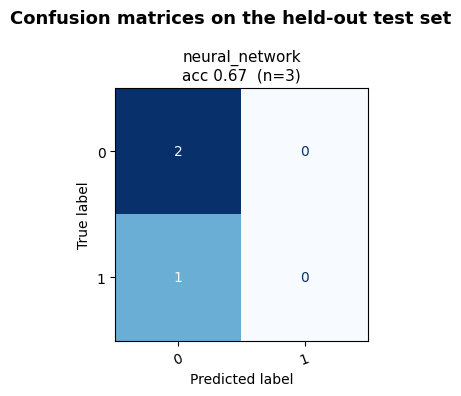

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

RECOMPUTE_CM_LOCALLY = False          # fallback when the service doesn't return confusion matrices
CM_DATASET_ID = "symbols_filtered"    # dataset the models were trained on (for the local fallback)
DATA_SERVICE_URL = "localhost:50051"
CM_LABELS = payload["config"].get("factor_values") or None


def plot_confusion_matrices(matrices, labels, title):
    """matrices: dict {name: 2D array}"""
    n = len(matrices)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 4.0 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (name, cm) in zip(axes, matrices.items()):
        cm = np.asarray(cm)
        acc = np.trace(cm) / cm.sum() if cm.sum() else 0
        disp_labels = labels if labels and len(labels) == cm.shape[0] else None
        ConfusionMatrixDisplay(cm, display_labels=disp_labels).plot(
            ax=ax, cmap="Blues", colorbar=False, values_format="d")
        ax.set_title(f"{name}\nacc {acc:.2f}  (n={int(cm.sum())})", fontsize=11)
        ax.tick_params(axis="x", labelrotation=20)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()


def local_cv_confusion_matrices(dataset_id, algorithms, target_col, labels):
    """Fallback: cross-validated predictions for each algorithm + majority vote."""
    import sys
    from pathlib import Path
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import StratifiedKFold, cross_val_predict
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import SVC

    for sub in ("feature_importance_service/src", "ml_service/src", "bioinformatics_service/src"):
        p = Path.cwd() / sub
        if (p / "data_client.py").exists():
            sys.path.insert(0, str(p))
            break
    from data_client import DataServiceClient

    client = DataServiceClient(service_url=DATA_SERVICE_URL)
    loader = next(getattr(client, m) for m in ("get_dataset", "load_dataset", "fetch_dataset", "stream_dataset")
                  if hasattr(client, m))
    df = loader(dataset_id)
    y = df[target_col].astype(str).values
    X = df.drop(columns=[target_col]).select_dtypes(include="number")

    try:
        from xgboost import XGBClassifier
        from sklearn.preprocessing import LabelEncoder
        xgb = XGBClassifier(eval_metric="logloss", random_state=42)
    except ImportError:
        xgb = GradientBoostingClassifier(random_state=42)

    zoo = {
        "random_forest": RandomForestClassifier(n_estimators=300, random_state=42),
        "logistic_regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
        "xgboost": xgb,
        "svm": make_pipeline(StandardScaler(), SVC()),
    }
    labels = labels or sorted(set(y))
    n_splits = min(5, pd.Series(y).value_counts().min())
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    preds = {}
    for algo in algorithms:
        if algo not in zoo:
            print(f"  skipping {algo}: no local equivalent")
            continue
        model = zoo[algo]
        if algo == "xgboost" and type(model).__name__ == "XGBClassifier":
            y_num = pd.Series(y).map({lab: i for i, lab in enumerate(labels)}).values
            preds[algo] = np.array(labels)[cross_val_predict(model, X, y_num, cv=cv)]
        else:
            preds[algo] = cross_val_predict(model, X, y, cv=cv)
    votes = pd.DataFrame(preds)
    preds["ensemble (majority vote)"] = votes.apply(
        lambda row: max(labels, key=lambda lab: (row == lab).sum()), axis=1).values
    return {name: confusion_matrix(y, p, labels=labels) for name, p in preds.items()}, labels, n_splits


if result:
    models = result.get("training_results", {}).get("test_metrics", {}).get("models", [])
    returned = {m.get("algorithm", f"model_{i}"): m["confusion_matrix"]
                for i, m in enumerate(models) if m.get("confusion_matrix") is not None}

    if returned:
        labels = next((m.get("labels") or m.get("class_labels") for m in models if m.get("labels") or m.get("class_labels")),
                      CM_LABELS)
        plot_confusion_matrices(returned, labels, "Confusion matrices on the held-out test set")
    elif RECOMPUTE_CM_LOCALLY:
        algos = payload["config"]["ensemble_algorithms"]
        target = payload["config"]["target_column"]
        mats, labels, k = local_cv_confusion_matrices(CM_DATASET_ID, algos, target, CM_LABELS)
        plot_confusion_matrices(mats, labels, f"Cross-validated confusion matrices ({k}-fold, {CM_DATASET_ID})")
    else:
        print("The ML service didn't return confusion matrices.")
        print("Either add 'confusion_matrix' to each model's test metrics in the ML service,")
        print("or set RECOMPUTE_CM_LOCALLY = True above to rebuild them here with cross-validation.")
else:
    print("Run pipeline first")

## Visualize Feature Importance

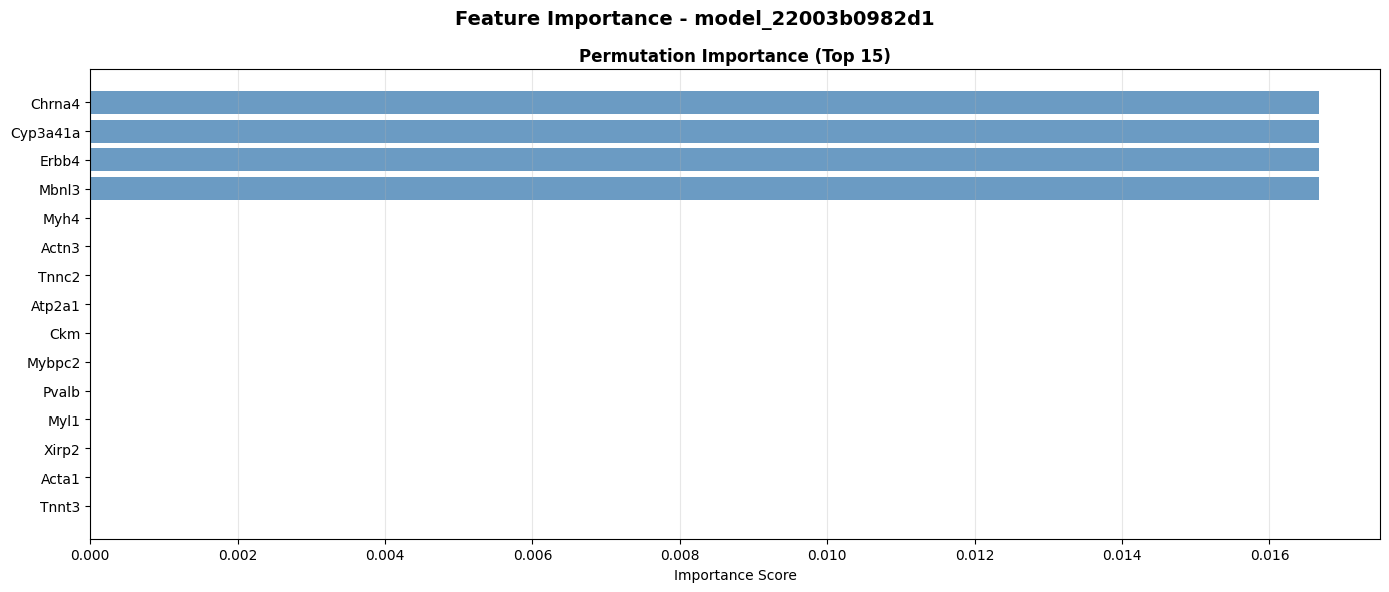

\nTop 10 Features by Permutation Importance (model_22003b0982d1):
 Rank  Feature  Importance
    1   Chrna4    0.016667
    2 Cyp3a41a    0.016667
    3    Erbb4    0.016667
    4    Mbnl3    0.016667
    5     Myh4    0.000000
    6    Actn3    0.000000
    7    Tnnc2    0.000000
    8   Atp2a1    0.000000
    9      Ckm    0.000000
   10   Mybpc2    0.000000


In [7]:
if result:
    fi_data = result.get('feature_importance', {})
    
    if fi_data:
        # Get first model's importance data
        first_model_id = list(fi_data.keys())[0] if fi_data else None
        
        if first_model_id:
            model_importance = fi_data[first_model_id]
            
            # Create subplot for each method
            methods = list(model_importance.keys())
            num_methods = len(methods)
            
            fig, axes = plt.subplots(1, min(num_methods, 2), figsize=(14, 6))
            if num_methods == 1:
                axes = [axes]
            
            fig.suptitle(f'Feature Importance - {first_model_id}', fontsize=14, fontweight='bold')
            
            for idx, method in enumerate(methods[:2]):
                if idx >= len(axes):
                    break
                    
                features_data = model_importance.get(method, {}).get('features', [])
                
                if features_data:
                    # Get top 15 features
                    top_features = sorted(features_data, key=lambda x: x.get('importance', 0), reverse=True)[:15]
                    
                    feature_names = [f.get('feature_name', 'unknown') for f in top_features]
                    importances = [f.get('importance', 0) for f in top_features]
                    
                    # Plot
                    axes[idx].barh(feature_names, importances, color='steelblue', alpha=0.8)
                    axes[idx].set_title(f'{method.capitalize()} Importance (Top 15)', fontweight='bold')
                    axes[idx].set_xlabel('Importance Score')
                    axes[idx].invert_yaxis()
                    axes[idx].grid(axis='x', alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            # Feature importance summary table
            print(f"\\nTop 10 Features by Permutation Importance ({first_model_id}):")
            if 'permutation' in model_importance:
                features = model_importance['permutation'].get('features', [])
                top_10 = sorted(features, key=lambda x: x.get('importance', 0), reverse=True)[:10]
                
                fi_df = pd.DataFrame({
                    'Rank': [f.get('rank', 0) for f in top_10],
                    'Feature': [f.get('feature_name', '') for f in top_10],
                    'Importance': [f.get('importance', 0) for f in top_10]
                })
                print(fi_df.to_string(index=False))
    else:
        print("No feature importance data available")
else:
    print("Run pipeline first")

## DESeq2 Differential Expression Analysis

In [8]:
if result:
    deseq2 = result.get('deseq2_results', {})
    
    if deseq2.get('success'):
        print(f"\nDESeq2 Analysis Results:")
        print(f"  Analysis ID: {deseq2.get('analysis_id')}")
        print(f"  Total genes analyzed: {deseq2.get('num_genes')}")
        print(f"  Significant genes (padj < 0.05): {deseq2.get('num_significant')}")
        print(f"    - Upregulated: {deseq2.get('num_upregulated')}")
        print(f"    - Downregulated: {deseq2.get('num_downregulated')}")
        
        # Top differential genes table
        #diff_genes = deseq2.get('differential_genes', [])
        diff_genes = [g for g in deseq2.get('differential_genes', []) if g['padj'] < 0.05]
        if diff_genes:
            top_genes = sorted(diff_genes, key=lambda x: abs(x.get('log2_fold_change', 0)), reverse=True)[:10]
            
            deseq_df = pd.DataFrame({
                'Gene ID': [g['gene_id'] for g in top_genes],
                'Log2FC': [g['log2_fold_change'] for g in top_genes],
                'P-value': [g['pvalue'] for g in top_genes],
                'Padj': [g['padj'] for g in top_genes],
                'BaseMean': [g['base_mean'] for g in top_genes]
            })
            
            print(f"\nTop 10 Differentially Expressed Genes:")
            print(deseq_df.to_string(index=False))
    else:
        error = deseq2.get('error', 'Unknown error')
        print(f"DESeq2 analysis failed: {error}")
else:
    print("Run pipeline first")


DESeq2 Analysis Results:
  Analysis ID: deseq2_symbols_filtered
  Total genes analyzed: 2000
  Significant genes (padj < 0.05): 0
    - Upregulated: 0
    - Downregulated: 0


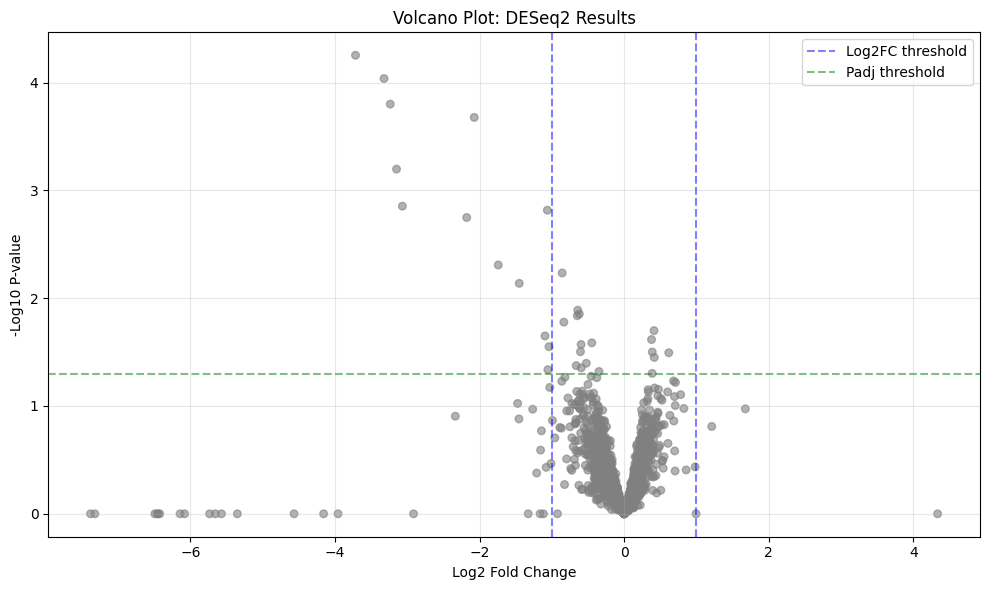

In [9]:
if result:
    deseq2 = result.get('deseq2_results', {})
    
    if deseq2.get('success'):
        diff_genes = deseq2.get('differential_genes', [])
        if diff_genes:
            fig, ax = plt.subplots(figsize=(10, 6))
            log2fc = [g['log2_fold_change'] for g in diff_genes]
            neg_log10_pval = [-np.log10(max(g['pvalue'], 1e-300)) for g in diff_genes]
            
            # Color by significance
            colors = ['red' if g['padj'] < 0.05 else 'gray' for g in diff_genes]
            
            ax.scatter(log2fc, neg_log10_pval, c=colors, alpha=0.6, s=30)
            ax.axvline(x=1, color='blue', linestyle='--', alpha=0.5, label='Log2FC threshold')
            ax.axvline(x=-1, color='blue', linestyle='--', alpha=0.5)
            ax.axhline(y=-np.log10(0.05), color='green', linestyle='--', alpha=0.5, label='Padj threshold')
            
            ax.set_xlabel('Log2 Fold Change')
            ax.set_ylabel('-Log10 P-value')
            ax.set_title('Volcano Plot: DESeq2 Results')
            ax.legend()
            ax.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()
else:
    print("Run pipeline first")

## Ensemble Consensus Genes

For each model, genes are ranked by each feature-importance method the model supports (SVM has no RFE),
and the method ranks are averaged. A gene gets one vote from each model that puts it in its top `TOP_N`.
Consensus genes are those with votes from a simple majority of models (`MIN_VOTES`).

In [10]:
TOP_N = 50                  # top genes per model
MIN_VOTES = None            # None = simple majority of models
MODEL_NAMES = {}            # optional {model_id: "random_forest", ...} for nicer labels


def model_rankings(fi_data):
    """{model_id: Series(gene -> mean rank across methods)}"""
    out = {}
    for model_id, methods in fi_data.items():
        ranks = []
        for method, payload_ in methods.items():
            feats = (payload_ or {}).get("features", [])
            if not feats:
                continue
            df_ = pd.DataFrame(feats)
            if "rank" in df_ and df_["rank"].notna().all() and df_["rank"].nunique() > 1:
                r = df_.set_index("feature_name")["rank"].astype(float)
            else:
                r = df_.set_index("feature_name")["importance"].rank(ascending=False, method="min")
            ranks.append(r.rename(method))
        if ranks:
            out[model_id] = pd.concat(ranks, axis=1).mean(axis=1).sort_values()
    return out


if result and result.get("feature_importance"):
    rankings = model_rankings(result["feature_importance"])
    n_models = len(rankings)
    min_votes = MIN_VOTES or (n_models // 2 + 1)

    top_sets = {MODEL_NAMES.get(m, m): set(r.index[:TOP_N]) for m, r in rankings.items()}
    votes = pd.Series([g for s in top_sets.values() for g in s]).value_counts()
    mean_rank = pd.concat(rankings.values(), axis=1).mean(axis=1)

    consensus_df = (pd.DataFrame({"gene": votes.index, "votes": votes.values})
                    .assign(mean_rank=lambda d: d["gene"].map(mean_rank).round(1))
                    .sort_values(["votes", "mean_rank"], ascending=[False, True])
                    .reset_index(drop=True))
    consensus_genes = consensus_df[consensus_df["votes"] >= min_votes]

    print(f"{n_models} models, top {TOP_N} genes each; consensus = votes >= {min_votes}")
    print(f"Consensus genes: {len(consensus_genes)}")
    print(consensus_df["votes"].value_counts().sort_index(ascending=False)
          .rename_axis("votes").rename("genes").to_string())
    print()
    print(consensus_genes.head(25).to_string(index=False))
else:
    print("Run pipeline first (no feature importance in result)")

1 models, top 50 genes each; consensus = votes >= 1
Consensus genes: 50
votes
1    50

    gene  votes  mean_rank
  Chrna4      1        1.0
Cyp3a41a      1        2.0
   Erbb4      1        3.0
   Mbnl3      1        4.0
    Myh4      1        5.0
   Actn3      1        6.0
   Tnnc2      1        7.0
  Atp2a1      1        8.0
     Ckm      1        9.0
  Mybpc2      1       10.0
   Pvalb      1       11.0
    Myl1      1       12.0
   Xirp2      1       13.0
   Acta1      1       14.0
   Tnnt3      1       15.0
     Ttn      1       16.0
    Ryr1      1       17.0
    Myh1      1       18.0
   Tnni2      1       19.0
   Dmbt1      1       20.0
   Mylpf      1       21.0
   Ciart      1       22.0
    Usp2      1       23.0
    Tsku      1       24.0
    A1bg      1       25.0


## ML Consensus Genes vs DESeq2

Which consensus genes are also differentially expressed? The hypergeometric p-value asks how likely an
overlap this large would be if the consensus genes were a random draw from the tested genes.
`gene_comparison.py` should be in `orchestration_service/src/` (or next to this notebook).

In [11]:
import sys
from pathlib import Path

for p in (Path.cwd() / "orchestration_service" / "src", Path.cwd()):
    if (p / "gene_comparison.py").exists():
        sys.path.insert(0, str(p))
        break
from gene_comparison import compare_genes

PADJ_THRESHOLD = 0.05
LOG2FC_THRESHOLD = 0.0

deseq2 = result.get("deseq2_results", {}) if result else {}
if result and deseq2.get("success") and "consensus_genes" in globals():
    deseq2_df = pd.DataFrame(deseq2.get("differential_genes", []))

    # Universe = genes both analyses could have picked
    ml_universe = set().union(*[set(r.index) for r in rankings.values()])
    de_universe = set(deseq2_df["gene_id"].astype(str))
    universe = ml_universe & de_universe if len(de_universe) >= 0.9 * deseq2.get("num_genes", 0) else ml_universe
    if len(de_universe) < 0.9 * deseq2.get("num_genes", 0):
        print(f"Note: DESeq2 returned {len(de_universe)} of {deseq2.get('num_genes')} genes; "
              "using the ML feature set as the universe.")

    cmp = compare_genes(consensus_genes, deseq2_df, universe=universe,
                        padj_threshold=PADJ_THRESHOLD, log2fc_threshold=LOG2FC_THRESHOLD)

    print(f"Consensus genes (ML):      {cmp['n_ml']}")
    print(f"DESeq2 significant genes:  {cmp['n_deseq2']}  (padj < {PADJ_THRESHOLD}, |log2FC| > {LOG2FC_THRESHOLD})")
    print(f"Genes tested (universe):   {cmp['n_universe']}")
    print(f"Overlap:                   {cmp['n_overlap']}  (expected by chance {cmp['expected_overlap']})")
    print(f"Fold enrichment:           {cmp['fold_enrichment']}")
    print(f"Hypergeometric p:          {cmp['hypergeom_pvalue']:.3g}")
    print(f"Jaccard:                   {cmp['jaccard']}")
    print(f"\nFound by both: {', '.join(cmp['overlap']) or '(none)'}")

    display(cmp["table"].style.format(
        {"ml_score": "{:.0f}", "log2FoldChange": "{:.2f}", "padj": "{:.2e}"}, na_rep="—"))
else:
    print("Needs a successful pipeline run with DESeq2 results and the consensus cell above.")

Consensus genes (ML):      50
DESeq2 significant genes:  0  (padj < 0.05, |log2FC| > 0.0)
Genes tested (universe):   2000
Overlap:                   0  (expected by chance 0.0)
Fold enrichment:           None
Hypergeometric p:          1
Jaccard:                   0.0

Found by both: (none)


,gene,ml_rank,ml_score,log2FoldChange,padj,in_ml,in_deseq2,category,direction
0,Chrna4,1,1,-0.31,1.00e+00,True,False,ml_only,down
1,Per3,2,1,-0.22,1.00e+00,True,False,ml_only,down
2,Gm56171,3,1,-2.34,1.00e+00,True,False,ml_only,down
3,Upk3b,4,1,-1.46,1.00e+00,True,False,ml_only,down
4,Gm56542,5,1,0.98,1.00e+00,True,False,ml_only,up
5,Dbp,6,1,-0.32,1.00e+00,True,False,ml_only,down
6,Gm24924,7,1,-1.47,1.00e+00,True,False,ml_only,down
7,Serpina4-ps1,8,1,0.86,1.00e+00,True,False,ml_only,up
8,Gm24514,9,1,-1.01,1.00e+00,True,False,ml_only,down
9,Myc,10,1,0.99,1.00e+00,True,False,ml_only,up


In [12]:
d = result["deseq2_results"]
print({k: v for k, v in d.items() if k != "differential_genes"})
print("differential_genes:", len(d.get("differential_genes", [])))

{'success': True, 'analysis_id': 'deseq2_symbols_filtered', 'num_genes': 2000, 'num_significant': 0, 'num_upregulated': 0, 'num_downregulated': 0, 'volcano_plot_path': '/app/results/deseq2_symbols_filtered/volcano_plot.png', 'ma_plot_path': '/app/results/deseq2_symbols_filtered/ma_plot.png'}
differential_genes: 2000


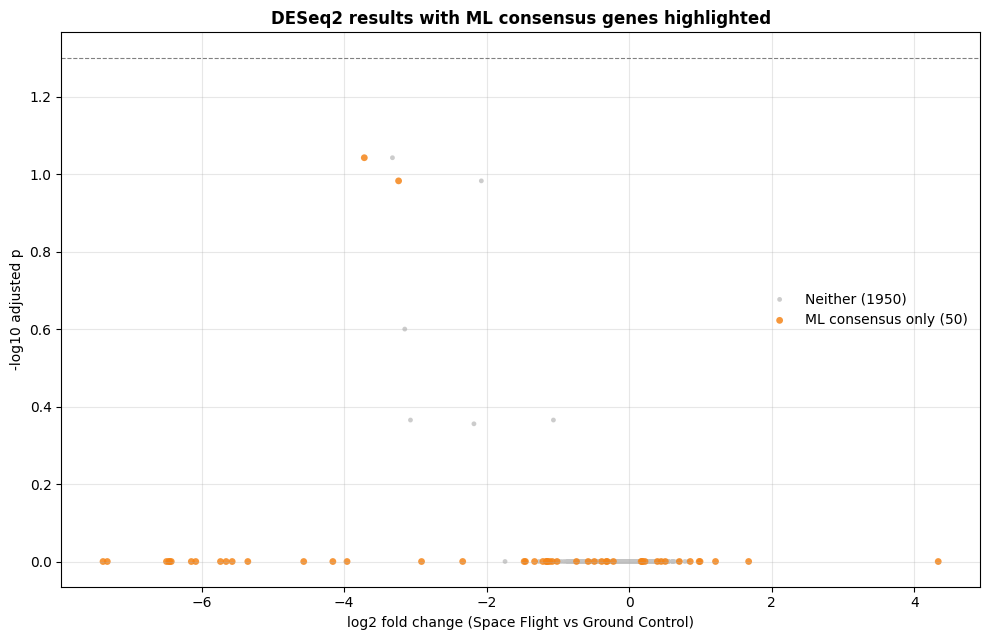

In [13]:
if "cmp" in globals():
    v = deseq2_df.copy()
    v["gene"] = v["gene_id"].astype(str)
    cat = cmp["table"].set_index("gene")["category"]
    v["category"] = v["gene"].map(cat).fillna("neither")
    v["neglog10_padj"] = -np.log10(v["padj"].astype(float).clip(lower=1e-300))

    style = {
        "neither":     dict(color="#c4c4c4", s=12, label="Neither"),
        "deseq2_only": dict(color="#4c78a8", s=20, label="DESeq2 only"),
        "ml_only":     dict(color="#f58518", s=24, label="ML consensus only"),
        "both":        dict(color="#d62728", s=44, label="Both"),
    }
    fig, ax = plt.subplots(figsize=(10, 6.5))
    for c, kw in style.items():
        sub = v[v["category"] == c]
        if len(sub):
            kw = dict(kw)
            ax.scatter(sub["log2_fold_change"], sub["neglog10_padj"], alpha=0.85, edgecolor="none",
                       label=f"{kw.pop('label')} ({len(sub)})", **kw)
    for _, r in v[v["category"] == "both"].nlargest(20, "neglog10_padj").iterrows():
        ax.annotate(r["gene"], (r["log2_fold_change"], r["neglog10_padj"]), fontsize=8,
                    xytext=(3, 3), textcoords="offset points")
    ax.axhline(-np.log10(PADJ_THRESHOLD), ls="--", lw=0.8, color="grey")
    fl = payload["config"].get("factor_values") or ["control", "treatment"]
    ax.set_xlabel(f"log2 fold change ({fl[-1]} vs {fl[0]})")
    ax.set_ylabel("-log10 adjusted p")
    ax.set_title("DESeq2 results with ML consensus genes highlighted", fontweight="bold")
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Save Results

In [14]:
if result:
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename = f"pipeline_results_{timestamp}.json"
    
    with open(filename, 'w') as f:
        json.dump(result, f, indent=2, default=str)
    
    print(f"✓ Results saved to {filename}")
    
    # Save ensemble metrics
    train = result.get('training_results', {})
    test_metrics = train.get('test_metrics', {})
    models = test_metrics.get('models', [])
    
    if models:
        # Create metrics DataFrame for all models
        metrics_data = []
        for model in models:
            metrics_data.append({
                'Algorithm': model.get('algorithm', ''),
                'Accuracy': model.get('accuracy', 0),
                'Precision': model.get('precision', 0),
                'Recall': model.get('recall', 0),
                'F1_Score': model.get('f1_score', 0)
            })
        
        metrics_df = pd.DataFrame(metrics_data)
        csv_file = f"ensemble_metrics_{timestamp}.csv"
        metrics_df.to_csv(csv_file, index=False)
        print(f"✓ Ensemble metrics saved to {csv_file}")

    if "consensus_df" in globals():
        consensus_df.to_csv(f"consensus_genes_{timestamp}.csv", index=False)
        print(f"✓ Consensus gene votes saved to consensus_genes_{timestamp}.csv")
    if "cmp" in globals():
        cmp["table"].to_csv(f"gene_comparison_{timestamp}.csv", index=False)
        print(f"✓ ML vs DESeq2 comparison saved to gene_comparison_{timestamp}.csv")
else:
    print("Run pipeline first")

✓ Results saved to pipeline_results_20261009_073915.json
✓ Ensemble metrics saved to ensemble_metrics_20261009_073915.csv
✓ Consensus gene votes saved to consensus_genes_20261009_073915.csv
✓ ML vs DESeq2 comparison saved to gene_comparison_20261009_073915.csv
